## 4. Model Training

Import all libraries

In [1]:
import pandas as pd
pd.set_option('display.max_columns', 100)

# data visualization
import matplotlib.pyplot as plt

# data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# model selection
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

# feature importance
from xgboost import plot_importance
from sklearn.inspection import permutation_importance

# regression models
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# ignore future warnings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


load dataset

In [2]:
df = pd.read_csv('final_df.csv')
df.head()

,base_price,departure_hour,arrival_hour,days_until_departure,trip_duration_minutes,number_of_stops,is_weekend_departure,origin_YVR,origin_YYC,origin_YYZ,destination_YVR,destination_YYC,destination_YYZ,Name_airline_Air North Yukon's Airline,Name_airline_Air Transat,Name_airline_Central Mountain Air LTD,Name_airline_Pacific Coastal Airlines Limited,Name_airline_Porter Airlines Canada Limited,Name_airline_WestJet,day_of_week_departure_Monday,day_of_week_departure_Saturday,day_of_week_departure_Sunday,day_of_week_departure_Thursday,day_of_week_departure_Tuesday,day_of_week_departure_Wednesday,departure_time_period_Early Morning,departure_time_period_Evening,departure_time_period_Late Evening,departure_time_period_Morning,departure_time_period_Night,arrival_time_period_Early Morning,arrival_time_period_Evening,arrival_time_period_Late Evening,arrival_time_period_Morning,arrival_time_period_Night,season_Spring,season_Summer,season_Winter,route_YOW-YYC,route_YOW-YYZ,route_YVR-YOW,route_YVR-YYC,route_YVR-YYZ,route_YYC-YOW,route_YYC-YVR,route_YYC-YYZ,route_YYZ-YOW,route_YYZ-YVR,route_YYZ-YYC
0,339,5,7,1,81,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0
1,339,6,8,1,75,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0
2,339,10,11,1,75,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0
3,339,15,16,1,75,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0
4,339,18,20,1,75,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0


In [3]:
df.shape

(43157, 49)

### XGBoost Model
XGBoost (eXtreme Gradient Boosting) regression is a powerful and efficient machine learning algorithm that uses an ensemble of decision trees to predict continuous numerical values

In [4]:
# input variables
X = df.drop('base_price', axis=1)

# target variable
y = df['base_price']

**Train Test Split**
* Training sets are used to fit and tune your models.
* Test sets are put aside as "unseen" data to evaluate your models.
* The `train_test_split()` function splits data into randomized subsets.
* We will opt for a traditional 70-30 split.

In [5]:
# split the dataset
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [6]:
# Define xgb as XGBRegressor
xgb = XGBRegressor(random_state=42, objective='reg:absoluteerror')  

# Define parameters 
cv_params = {
    'n_estimators': [500],
    'learning_rate': [0.05],
    'max_depth': [6],
    'subsample': [0.8],
    'colsample_bytree': [0.7],
}

# Construct GridSearch
xgb_cv = GridSearchCV(xgb, cv_params, cv=5,
                      scoring='neg_mean_absolute_error',
                      refit=True, n_jobs=-1)

# fit the GridSearch model to training data
xgb_cv = xgb_cv.fit(x_train,y_train)
print("Best params:", xgb_cv.best_params_)

Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 500, 'subsample': 0.8}


In [7]:
# Apply your model to predict on your test data. Call this output "y_pred"
best_model = xgb_cv.best_estimator_
test_pred = best_model.predict(x_test)
train_pred = best_model.predict(x_train)

print(f'Training MAE: {mean_absolute_error(y_train, train_pred):.2f}')
print(f'Training R2: {r2_score(y_train, train_pred):.3f}')

print(f'Test MAE: {mean_absolute_error(y_test, test_pred):.2f}')
print(f'Test R2: {r2_score(y_test, test_pred):.3f}')

Training MAE: 37.44
Training R2: 0.746
Test MAE: 39.98
Test R2: 0.722


<Figure size 1200x1200 with 0 Axes>

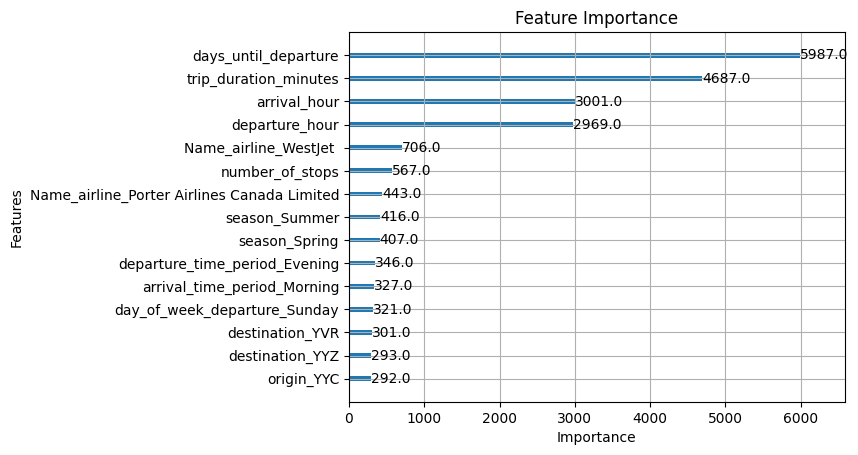

In [8]:
# Plot the relative feature importance of the predictor variables in your model.
plt.figure(figsize=(12, 12))
plot_importance(xgb_cv.best_estimator_, max_num_features=15)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

### Random Forest
Random Forest Regression is a powerful ensemble machine learning algorithm that predicts continuous numerical values by averaging the results of multiple decision trees trained on random subsets of the data. By training trees on different samples (bagging) and using only a subset of features for splits, it reduces variance, controls overfitting, and handles high-dimensional data better than individual trees

In [ ]:
# Now we will train a Random Forest model and compare the results with XGBoost
rf = RandomForestRegressor(random_state=42, n_jobs = -1)

# Define parameters for GridSearch
cv_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [5, 10],
    'max_features': ['sqrt', 0.5]
}

# Construct GridSearch
rf_cv = GridSearchCV(rf, cv_params, cv=5,
                     scoring='neg_mean_absolute_error', refit=True, n_jobs=-1)
rf_cv.fit(x_train, y_train)
print("Best params:", rf_cv.best_params_)

Best params: {'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 200}


In [ ]:
# Apply your model to predict on your test data 
best_rf = rf_cv.best_estimator_
test_pred = best_rf.predict(x_test)
train_pred = best_rf.predict(x_train)

print(f'Training MAE: {mean_absolute_error(y_train, train_pred):.2f}')
print(f'Training R2: {r2_score(y_train, train_pred):.3f}')

print(f'Test MAE: {mean_absolute_error(y_test, test_pred):.2f}')
print(f'Test R2: {r2_score(y_test, test_pred):.3f}')

Training MAE: 30.84
Training R2: 0.866
Test MAE: 36.65
Test R2: 0.809


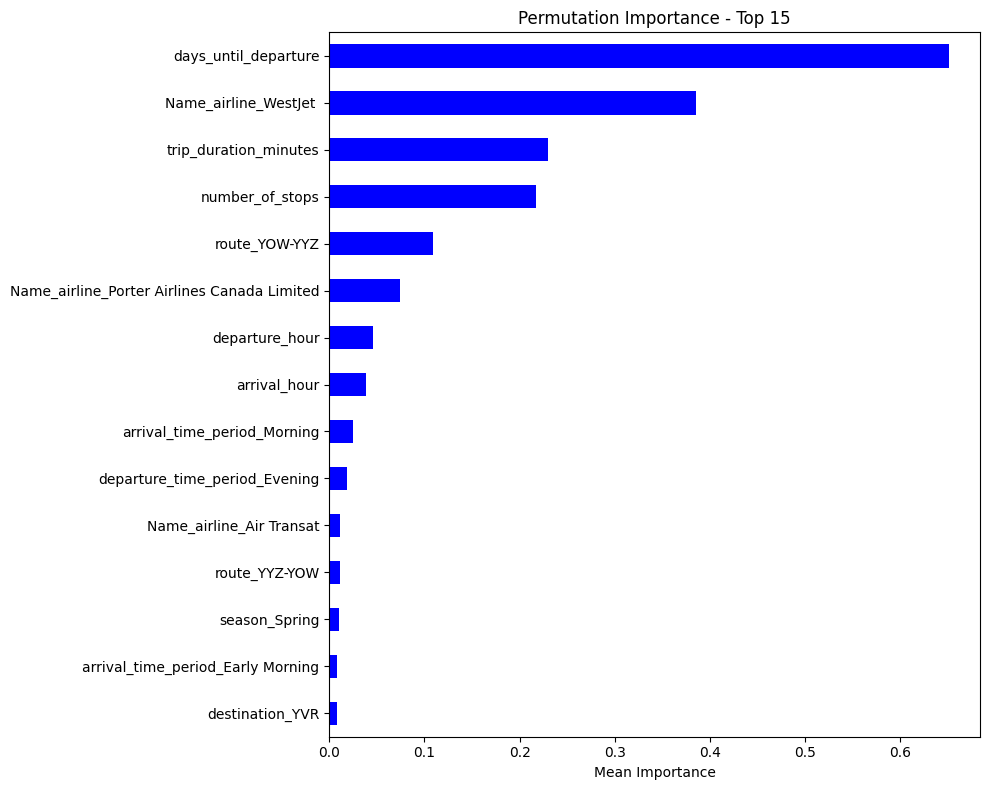

In [11]:
# Plot the relative feature importance of the predictor variables in your model.
perm_imp = permutation_importance(best_rf, x_test, y_test, n_repeats=10, random_state=42)

perm_series = pd.Series(perm_imp.importances_mean, index=X.columns).sort_values(ascending=True)
perm_series.tail(15).plot(kind='barh', figsize=(10, 8), color='blue')
plt.title('Permutation Importance - Top 15')
plt.xlabel('Mean Importance')
plt.tight_layout()
plt.show()

### Model Comparison

In [12]:
# create a results dataframe to store the evaluation metrics for each model
results = pd.DataFrame(columns = ['Model', 'Train MAE', 'Train R2', 'Test MAE', 'Test R2'])

# function to add results to the dataframe
def add_results(model_name, model_object):
    train_pred = model_object.predict(x_train)
    test_pred = model_object.predict(x_test)
    train_mae = mean_absolute_error(y_train, train_pred)
    train_r2 = r2_score(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)
    test_r2 = r2_score(y_test, test_pred)

    result_dict = {
        'Model': model_name,
        'Train MAE': train_mae,
        'Train R2': train_r2,
        'Test MAE': test_mae,
        'Test R2': test_r2
    }

    table = pd.DataFrame(result_dict, index=[0])

    return table

# add results for both models
results = pd.concat([results, add_results('XGBoost', best_model)], ignore_index=True)
results = pd.concat([results, add_results('Random Forest', best_rf)], ignore_index=True)
results

,Model,Train MAE,Train R2,Test MAE,Test R2
0,XGBoost,37.440974,0.745607,39.979953,0.721749
1,Random Forest,30.836139,0.865600,36.645112,0.808515


### Evaluation

**Predictive Power**

Random Forest achieves a test R² of 0.809 — explaining 81% of variance in flight base prices — while XGBoost falls notably behind at 0.722. This is a meaningful gap; XGBoost is no longer a competitive alternative at these hyperparameters.

**Prediction Error**

Random Forest produces a lower test MAE ($36.65 vs $39.98) — roughly $3 less average error per prediction. Given that prices range from ~$34 to $2,365 with a mean of ~$308, a $36.65 MAE represents about 18.6% of the average price. While functional, this leaves room for improvement through target log-transformation or further hyperparameter tuning.

**Generalisation (Overfitting)**

Random Forest has a train/test R² gap of 0.057, indicating healthy generalisation. XGBoost shows a much tighter gap (0.024), but this is not a sign of good fit — its lower train R² (0.746) indicates the model is underfitting, failing to capture the complexity of pricing patterns even on training data.

**Selected Model**: Random Forest
Random Forest is selected as the final model based on:
- Lower test MAE — $36.65 vs $39.98, $3.33 more accurate per prediction
- Significantly higher test R² — 0.809 vs 0.722, an 8.7-point advantage
- Better generalisation — learns pricing patterns without underfitting

XGBoost underperforms here due to underfitting. It could close the gap with a higher n_estimators, lower learning_rate, and deeper max_depth, but Random Forest is the clear choice at current configurations.